# Chapter 4: Decision boundaries and image similarity

We will first explore how model hyperparameters change decision boundaries on a two-feature dataset. Then we will represent animal images as numerical features and use k-NN and an RBF SVM to classify them.

By the end, you should be able to connect model complexity to training and held-out accuracy, explain why image representations matter for distance-based models, and interpret nearest-neighbour results.

## Setup and imports

From this notebook's directory (`content/classes/varada`), run:

```sh
uv sync --locked
uv run --locked jupyter lab lecture-4-demo.ipynb
```

In VS Code, select this directory's `.venv` as the notebook kernel. Run the cells in order and keep the kernel running while using the sliders. The dependencies are recorded in `pyproject.toml` and `uv.lock`.

The first section needs only the tabular-data and plotting libraries. We will import PyTorch when we reach the image example.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import mglearn
import numpy as np
import pandas as pd
import panel as pn

from sklearn.datasets import load_iris
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline
# Use Panel's native JupyterLab renderer rather than the ipywidgets bridge.
pn.extension(comms="default")
pd.set_option("display.max_colwidth", 200)

# Start Jupyter from the directory containing this notebook.
DATA_DIR = Path.cwd() / "data"

<br><br>

## Decision boundaries playground

In this interactive playground, you will investigate how various algorithms create decision boundaries to distinguish between Iris flower species using their sepal length and width as features. By adjusting the parameters, you can observe how the decision boundaries change, which can result in either overfitting (where the model fits the training data too closely) or underfitting (where the model is too simplistic).

- With **k-Nearest Neighbours ($k$-NN)**, you'll determine how many neighboring flowers to consult. Should we rely on a single nearest neighbor? Or should we consider a wider group? 

- With **Support Vector Machine (SVM)** using the RBF kernel, you'll tweak the hyperparameters `C` and `gamma` to explore the tightrope walk between overly complex boundaries (that might overfit) and overly broad ones (that might underfit).
  
- With **Decision trees**, you'll observe the effect of `max_depth` on the decision boundary. 

Observe the process of refining decision boundaries, one parameter at a time! 

We keep only the two non-setosa species and use sepal length and width so we can draw the boundary in two dimensions. A fixed, stratified train/test split makes slider comparisons reproducible. The points below are training examples.

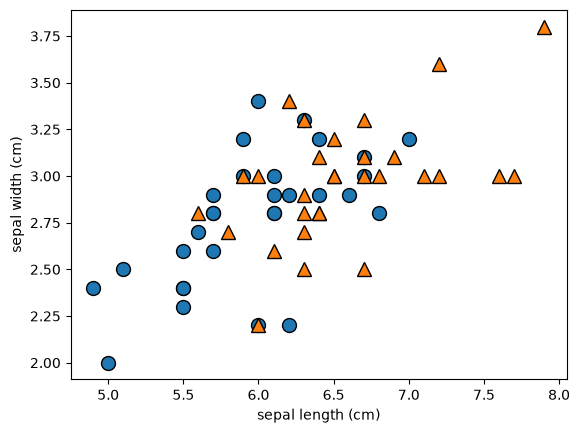

In [2]:
# Keep Iris variables separate from the animal-image variables below.
iris = load_iris(as_frame=True)
iris_df = iris.frame.loc[iris.target > 0].copy()
iris_X = iris_df[["sepal length (cm)", "sepal width (cm)"]]
iris_y = iris_df["target"]
iris_X_train, iris_X_test, iris_y_train, iris_y_test = train_test_split(
    iris_X, iris_y, test_size=0.4, random_state=123, stratify=iris_y
)

mglearn.discrete_scatter(
    iris_X_train.iloc[:, 0], iris_X_train.iloc[:, 1], iris_y_train, s=10
)
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.show()

### Explore model complexity

The shaded regions show predictions; the points are training examples. Each panel reports training and held-out test accuracy. The SVM sliders use base-10 logarithms: `0` means `1`, `1` means `10`, and `-1` means `0.1`.

Try changing one control at a time:

- Compare `k=1` with `k=40`. How smooth is the boundary?
- Increase tree depth. Does higher training accuracy always help test accuracy?
- Increase `gamma`, then change `C`. Can you create small, isolated prediction regions?

The held-out scores are for exploration here. Repeatedly choosing settings based on this test split would make it part of model selection rather than an unbiased final evaluation.

Panel binds the four controls to a plotting function and displays the result inline. This demo uses [Panel's native notebook rendering](https://panel.holoviz.org/how_to/notebook/notebook.html) in JupyterLab. Run the setup and playground cells in JupyterLab to use the sliders.

In [3]:
def plot_results(model, title, ax):
    """Fit on Iris training data and show its boundary and accuracy."""
    model.fit(iris_X_train.to_numpy(), iris_y_train)
    mglearn.plots.plot_2d_separator(
        model, iris_X_train.to_numpy(), fill=True, alpha=0.4, ax=ax
    )
    mglearn.discrete_scatter(
        iris_X_train.iloc[:, 0], iris_X_train.iloc[:, 1], iris_y_train, s=6, ax=ax
    )
    ax.set_xlabel("sepal length (cm)")
    ax.set_ylabel("sepal width (cm)")
    train_score = model.score(iris_X_train.to_numpy(), iris_y_train)
    test_score = model.score(iris_X_test.to_numpy(), iris_y_test)
    ax.set_title(f"{title}\ntrain={train_score:.2f}, test={test_score:.2f}", fontsize=12)


def update_plots(log10_c=0.0, log10_gamma=0.0, n_neighbors=5, max_depth=3):
    """Build a fresh figure whenever a slider changes."""
    c, gamma = 10**log10_c, 10**log10_gamma
    fig = Figure(figsize=(15, 5), layout="constrained")
    axes = fig.subplots(1, 3)
    models = [
        SVC(C=c, gamma=gamma),
        KNeighborsClassifier(n_neighbors=n_neighbors),
        DecisionTreeClassifier(max_depth=max_depth, random_state=42),
    ]
    titles = [
        f"SVM (C={c:.2g}, gamma={gamma:.2g})",
        f"k-NN (k={n_neighbors})",
        f"Decision tree (depth={max_depth})",
    ]
    for model, title, ax in zip(models, titles, axes):
        plot_results(model, title, ax)
    return fig


c_slider = pn.widgets.FloatSlider(name="log10(C)", start=-3, end=5, step=0.1, value=0)
gamma_slider = pn.widgets.FloatSlider(name="log10(gamma)", start=-3, end=5, step=0.1, value=0)
k_slider = pn.widgets.IntSlider(name="Number of neighbours (k)", start=1, end=40, value=5)
depth_slider = pn.widgets.IntSlider(name="Maximum tree depth", start=1, end=20, value=3)

# Panel controls the displayed size in pixels; figsize controls the figure layout.
PLOT_WIDTH = 1000
PLOT_HEIGHT = 300

boundary_plot = pn.pane.Matplotlib(
    pn.bind(update_plots, c_slider, gamma_slider, k_slider, depth_slider),
    format="svg",
    tight=True,
    width=PLOT_WIDTH,
    height=PLOT_HEIGHT,
    sizing_mode="fixed",
)
dashboard = pn.Column(
    pn.Row(pn.Column(c_slider, gamma_slider), pn.Column(k_slider, depth_slider)),
    boundary_plot,
    width=PLOT_WIDTH + 20,
    sizing_mode="fixed",
)
dashboard

Column(sizing_mode='fixed', width=1020)
    [0] Row
        [0] Column
            [0] FloatSlider(end=5, label='log10(C)', name='log10(C)', start=-3)
            [1] FloatSlider(end=5, label='log10(gamma)', name='log10(gamma)', start=-3)
        [1] Column
            [0] IntSlider(end=40, label='Number of neighbours (..., name='Number of neighbours (..., start=1, value=5)
            [1] IntSlider(end=20, label='Maximum tree depth', name='Maximum tree depth', start=1, value=3)
    [1] Matplotlib(Figure, format='svg', height=300, sizing_mode='fixed', tight=True, width=1000)

<br><br><br><br>

For the image example, we use a small subset of [Kaggle's Animal Faces dataset](https://www.kaggle.com/datasets/andrewmvd/animal-faces), stored locally in `data/animal_faces`. Each split contains folders named `cat`, `dog`, and `wild`.

The image-loading and neural-network code is supporting machinery; you are not expected to reproduce it. Focus on the inputs and outputs: **images $\to$ numerical representations $\to$ a classifier or similarity search**.

<br><br>

## Image classification using KNNs and SVM RBF

### Load and inspect the images

`ImageFolder` assigns an integer label to each class folder. We resize images to a common shape and convert their pixels to tensors. For this small dataset, we keep the images in memory, in a fixed order so images and labels stay aligned.

The loader checks that the directory contains JPEG images. `Path` joins keep these paths portable across operating systems.

In [4]:
import torch
from torchvision import datasets, models, transforms, utils

IMAGE_SIZE = 224


def read_img_dataset(data_dir):
    """Return image tensors in [0, 1], integer labels, and class names."""
    data_dir = Path(data_dir)
    image_paths = {path.resolve() for path in data_dir.glob("*/*.jpg")}
    if not image_paths:
        raise FileNotFoundError(f"No JPEG images found in {data_dir.resolve()}")
    image_dataset = datasets.ImageFolder(
        root=data_dir,
        # Exclude nested Jupyter checkpoint copies.
        is_valid_file=lambda path: Path(path).resolve() in image_paths,
        transform=transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
        ]),
    )
    loader = torch.utils.data.DataLoader(
        image_dataset, batch_size=len(image_dataset), shuffle=False, num_workers=0
    )
    inputs, labels = next(iter(loader))
    return inputs, labels, image_dataset.classes

In [5]:
def plot_sample_imgs(inputs):
    grid = utils.make_grid(inputs, nrow=8, padding=2)
    plt.figure(figsize=(12, 5))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title("Sample training images")
    plt.axis("off")
    plt.show()

In [6]:
train_dir = DATA_DIR / "animal_faces" / "train"
X_anim_train, y_train, class_names = read_img_dataset(train_dir)
print(f"Training images: {len(y_train)}; classes: {class_names}")

Training images: 150; classes: ['cat', 'dog', 'wild']


In [7]:
valid_dir = DATA_DIR / "animal_faces" / "valid"
X_anim_valid, y_valid, valid_class_names = read_img_dataset(valid_dir)
assert class_names == valid_class_names, "Class labels must match across splits."
print(f"Validation images: {len(y_valid)}")

Validation images: 150


The image tensors have shape `(number of images, colour channels, height, width)`. NumPy views will let us display the same images later alongside their neighbours.

In [8]:
X_train = X_anim_train.numpy()
X_valid = X_anim_valid.numpy()

Let's examine some of the sample images. 

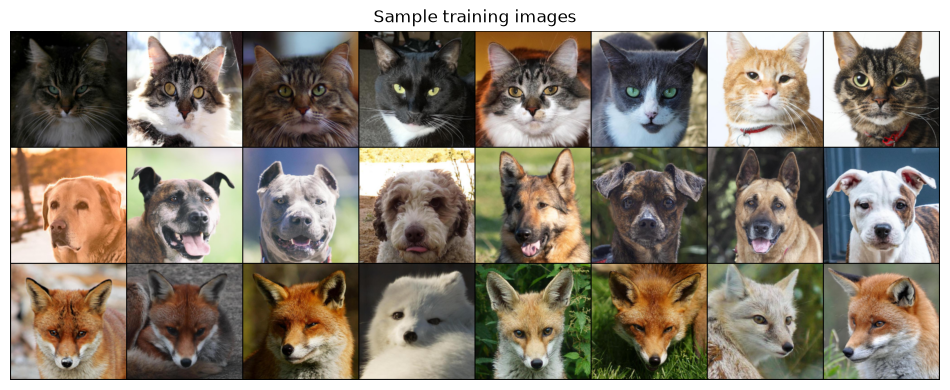

In [9]:
# Sample across the class folders rather than showing only the first class.
sample_indices = np.linspace(0, len(X_anim_train) - 1, 24, dtype=int)
plot_sample_imgs(X_anim_train[sample_indices])

With K-nearest neighbours (KNN), we will attempt to classify an animal face into one of three categories: cat, dog, or wild animal. The idea is that when presented with a new animal face image, we want the model to assign it to one of these three classes based on its similarity to other images within each of these classes.

To train a KNN model, we require tabular data. How can we transform image data, which includes height and width information, into tabular data with meaningful numerical values?

<br><br>

### Turn pixels into features

Flattening pixels is possible, but pixel distance may reflect lighting or background more than animal identity. Instead, we use a pretrained **DenseNet121** to map each image to 1,024 numerical features. We remove its final classifier and keep its learned representation; we are not training a neural network here.

The first model-loading run downloads pretrained weights and needs internet access. Later runs use the cached weights. We apply the weights' recommended preprocessing and use evaluation mode so feature extraction does not update the network's statistics. See [Torchvision's pretrained-model guidance](https://docs.pytorch.org/vision/main/models).

The helper processes small batches to limit memory use. Its output is a familiar table: one row per image and one column per feature.

In [10]:
def get_features(model, inputs, preprocess, batch_size=16):
    """Extract one 1,024-dimensional feature vector per image."""
    model.eval()
    features = []
    with torch.inference_mode():
        for batch in inputs.split(batch_size):
            features.append(model(preprocess(batch)).cpu())
    return torch.cat(features).numpy()

Load the pretrained network once. Replacing its classifier with an identity operation makes it return feature vectors instead of ImageNet class scores.

In [11]:
weights = models.DenseNet121_Weights.IMAGENET1K_V1
preprocess = weights.transforms()
densenet = models.densenet121(weights=weights)
densenet.classifier = torch.nn.Identity()
densenet.eval();

In [12]:
X_train.shape

(150, 3, 224, 224)

In [13]:
Z_train = get_features(densenet, X_anim_train, preprocess)

We now have tabular data. 

In [14]:
Z_train.shape

(150, 1024)

In [15]:
pd.DataFrame(Z_train)

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0.000174,0.002785,0.003991,0.001878,0.145329,0.235545,0.000197,0.001038,0.204713,0.000104,...,0.746599,2.249144,1.230401,0.151081,1.491349,0.668940,0.287033,0.604191,0.159410,0.249596
1,0.000223,0.004156,0.005684,0.001512,0.134704,0.718335,0.000243,0.000995,0.267202,0.000155,...,1.703884,0.469892,1.228050,0.271396,2.066193,2.203798,0.552362,2.331882,0.914751,0.341509
2,0.000133,0.005154,0.005746,0.001499,0.109613,0.793457,0.000289,0.001778,0.176317,0.000149,...,1.258019,1.036618,1.060935,0.128881,1.412923,1.694787,0.402036,1.995748,0.519304,0.408502
3,0.000146,0.007141,0.004325,0.001283,0.157750,0.665620,0.000242,0.002866,0.147522,0.000178,...,1.024373,1.361957,1.397628,0.039536,1.527091,1.827482,0.307669,2.185185,0.173883,0.624786
4,0.000372,0.004608,0.004703,0.001919,0.156398,0.610986,0.000184,0.002238,0.112964,0.000155,...,1.272539,0.889508,1.148670,0.170189,1.891502,2.149132,0.530697,2.862214,0.166716,0.423801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.000481,0.008993,0.006165,0.002665,0.268229,0.580981,0.000142,0.002559,0.185169,0.000152,...,0.905942,1.089621,1.132490,0.175628,2.924782,0.207031,0.650190,1.201576,0.141469,1.175516
146,0.000250,0.006372,0.005262,0.002629,0.153549,0.144821,0.000176,0.002076,0.193317,0.000152,...,0.441073,0.674909,0.281554,0.300391,0.723091,0.164314,0.057006,0.884130,0.546997,0.993637
147,0.000073,0.001105,0.005727,0.000048,0.122765,0.278650,0.000174,0.001207,0.051652,0.000675,...,0.401762,0.234061,0.457261,0.585136,0.340275,0.278410,0.371513,2.310418,0.128775,0.376256
148,0.000227,0.002557,0.007262,0.002943,0.096791,0.218253,0.000164,0.000644,0.130262,0.000346,...,0.664981,0.284891,0.483954,0.476333,0.570101,0.331871,0.640545,0.663948,0.230235,0.276206


Apply exactly the same fixed feature extractor to the validation images. No fitting or hyperparameter selection uses this split.

In [16]:
Z_valid = get_features(densenet, X_anim_valid, preprocess)

In [17]:
Z_valid.shape

(150, 1024)

<br><br>

### Dummy model

Before fitting a distance-based classifier, establish a baseline. `DummyClassifier` ignores the features and predicts the most frequent training class.

We use five-fold cross-validation on the **training split** to compare models. Each fold fits on four parts and scores on the remaining part. The image validation split stays separate from hyperparameter selection.

In [18]:
dummy = DummyClassifier()
pd.DataFrame(cross_validate(dummy, Z_train, y_train, cv=5, return_train_score=True))

,fit_time,score_time,test_score,train_score
0,0.000496,0.000464,0.333333,0.333333
1,0.000364,0.000174,0.333333,0.333333
2,0.000126,0.000151,0.333333,0.333333
3,0.000113,0.000146,0.333333,0.333333
4,0.000168,0.000153,0.333333,0.333333


## Classification with `KNeighborsClassifier`

In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
pd.DataFrame(cross_validate(knn, Z_train, y_train, return_train_score=True))

,fit_time,score_time,test_score,train_score
0,0.000875,0.028127,0.933333,0.975000
1,0.000390,0.000650,1.000000,1.000000
2,0.000246,0.000607,0.966667,0.983333
3,0.000229,0.000786,1.000000,0.991667
4,0.000257,0.000738,0.966667,0.975000


The default k-NN model uses five neighbours. A small `k` can fit local details closely; a larger `k` averages over more examples.

Next, we compare `k=1` through `14` using the same five-fold splits. We record mean training and cross-validation accuracy, plus their variation across folds. Choose `k` using cross-validation accuracy, not training accuracy.

In [20]:
knn.get_params()['n_neighbors']

5

For each candidate `k`, fit and evaluate a fresh classifier across five folds. The resulting table lets us compare performance and fold-to-fold variability.

In [21]:
n_neighbors = np.arange(1, 15, 1).tolist()

results_dict = {
    "n_neighbors": [],
    "mean_train_score": [],
    "mean_cv_score": [],
    "std_cv_score": [],
    "std_train_score": [],
}

for k in n_neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_validate(knn, Z_train, y_train, return_train_score=True)
    results_dict["n_neighbors"].append(k)

    results_dict["mean_cv_score"].append(np.mean(scores["test_score"]))
    results_dict["mean_train_score"].append(np.mean(scores["train_score"]))
    results_dict["std_cv_score"].append(scores["test_score"].std())
    results_dict["std_train_score"].append(scores["train_score"].std())

In [22]:
results_df = pd.DataFrame(results_dict)
results_df = results_df.set_index("n_neighbors")
results_df

,mean_train_score,mean_cv_score,std_cv_score,std_train_score
n_neighbors,,,,
1,1.000000,0.993333,0.013333,0.000000
2,1.000000,0.993333,0.013333,0.000000
3,0.998333,0.993333,0.013333,0.003333
4,0.996667,0.986667,0.016330,0.006667
5,0.985000,0.973333,0.024944,0.009718
6,0.986667,0.960000,0.032660,0.006667
7,0.973333,0.953333,0.033993,0.003333
8,0.971667,0.953333,0.026667,0.004082
9,0.961667,0.940000,0.024944,0.006667


Plot training and cross-validation accuracy against `k`. A gap can suggest overfitting, but use the cross-validation curve to choose among the candidates.

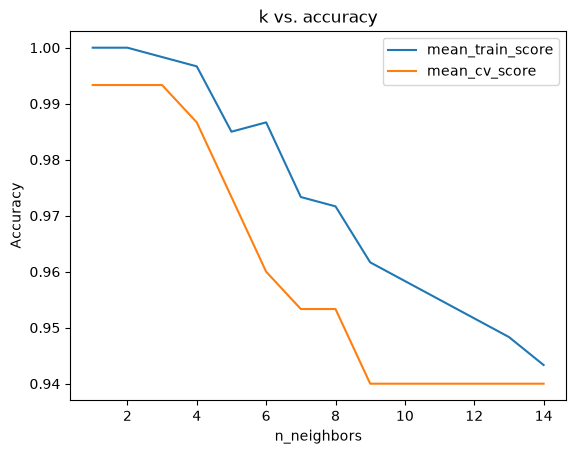

In [23]:
results_df[['mean_train_score', 'mean_cv_score']].plot(ylabel='Accuracy', title="k vs. accuracy");

Select the candidate with the highest mean cross-validation accuracy. If candidates tie, this expression picks the first (smallest) `k`.

In [24]:
best_k = n_neighbors[np.argmax(results_df['mean_cv_score'])]
best_k

1

Cross-validation selected k=1, favouring a flexible, very local decision rule. In this learned feature space, the closest training image was a useful guide to the label. Including more neighbours did not improve cross-validation accuracy.

### Compare an RBF SVM

Can an RBF SVM improve on k-NN using the same image features? We vary `C` across several orders of magnitude while keeping `gamma` at scikit-learn's default (`"scale"`). Larger `C` penalizes training errors more strongly.

As before, compare mean cross-validation accuracy. This is a small illustrative search, not an exhaustive tuning procedure.

In [25]:
C_values = np.logspace(-1, 2, 4)
cv_scores = []
train_scores = []

for C_val in C_values:
    print('C = ', C_val)
    svc = SVC(C=C_val)
    scores = cross_validate(svc, Z_train, y_train, return_train_score=True)
    cv_scores.append(scores['test_score'].mean())
    train_scores.append(scores['train_score'].mean())    

C =  0.1
C =  1.0
C =  10.0
C =  100.0


In [26]:
results_df = pd.DataFrame({"cv": cv_scores, 
                           "train": train_scores},index = C_values)
results_df

,cv,train
0.1,1.0,1.0
1.0,1.0,1.0
10.0,1.0,1.0
100.0,1.0,1.0


Select `C` by mean cross-validation accuracy, using the same rule as for `k`.

In [27]:
best_C = C_values[np.argmax(results_df['cv'])]
best_C

np.float64(0.1)

Read the table above to see which `C` works best on these folds. High accuracy on this small, curated subset does not imply equally strong performance on unfamiliar animal photos.

**Discuss:** Have we shown that this model works well on animal images generally, or that it works well on this small subset using DenseNet features? What experiment would help us tell?

### Inspect nearest neighbours

Accuracy summarizes predictions, but looking at neighbours reveals what the representation considers similar. We fit a search index on the training features and query it with validation images. These examples are for qualitative inspection, not hyperparameter selection.

For each query, the next cell shows its five nearest **training** images. Distance is measured in DenseNet feature space, not directly between pixels; smaller means closer. Compare animal identity, pose, colour, and background. Do the neighbours agree with your own idea of similarity?

In [28]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors()
nn.fit(Z_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'eu...an'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [29]:
def show_nearest_neighbors(test_idx, nn, query_features, query_images, query_labels):
    """Display a validation query and its nearest training examples."""
    distances, neighbors = nn.kneighbors(query_features[[test_idx]])
    plt.figure(figsize=(2, 2), dpi=80)
    plt.imshow(query_images[test_idx].transpose(1, 2, 0))
    plt.title(f"Query: {class_names[int(query_labels[test_idx])]}")
    plt.axis("off")
    plt.show()

    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    for ax, distance, index in zip(axes, distances[0], neighbors[0]):
        ax.imshow(X_train[index].transpose(1, 2, 0))
        ax.set_title(f"{class_names[int(y_train[index])]}\ndistance: {distance:.2f}")
        ax.axis("off")
    fig.tight_layout()
    plt.show()

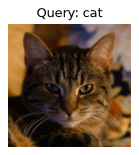

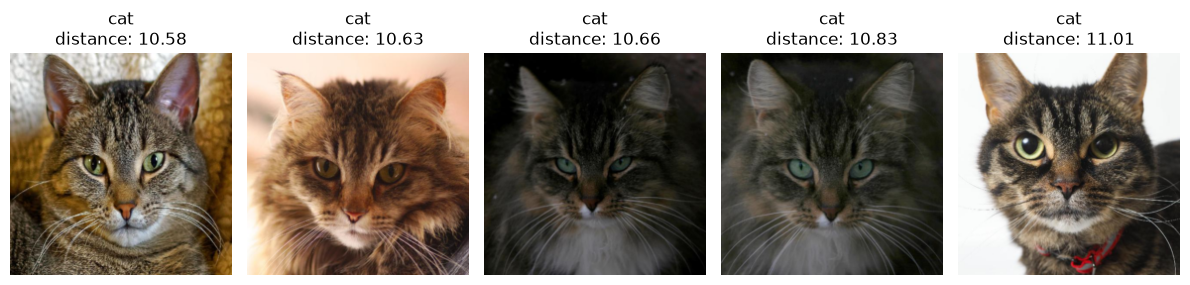

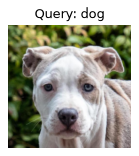

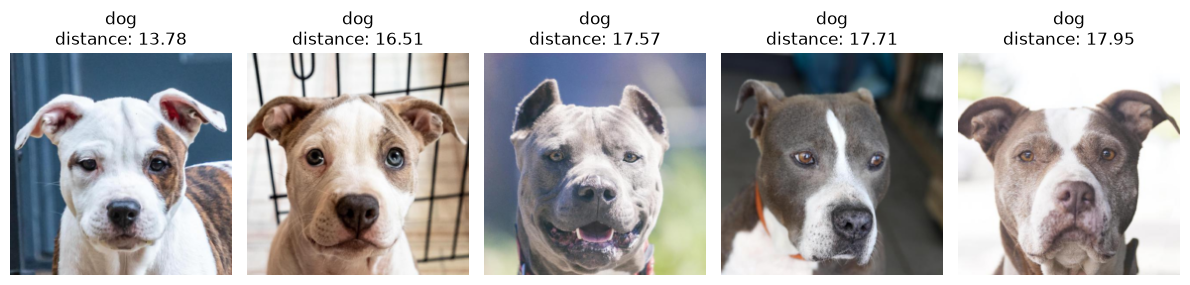

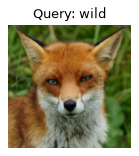

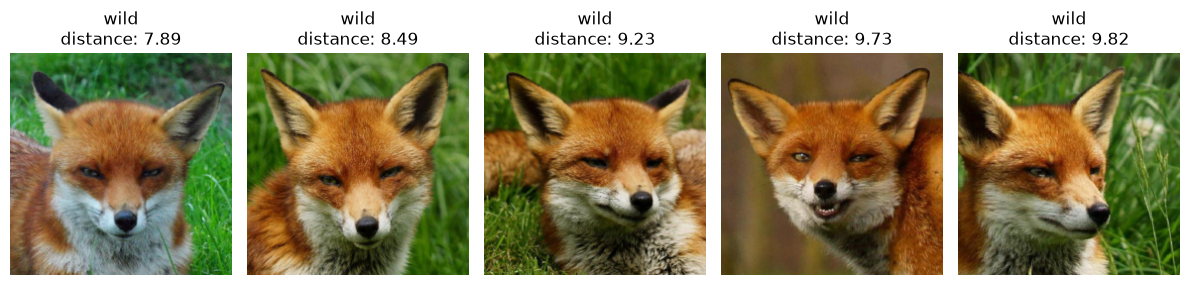

In [30]:
test_indices = [1, 52, 102]
for index in test_indices:
    show_nearest_neighbors(index, nn, Z_valid, X_valid, y_valid)

We can use $k$-NNs for more than just classifying images; we can also find the most similar examples in a dataset. You can see how this would be useful in recommendation systems. For instance, if a user is purchasing an item, you can find similar items in the dataset and recommend them to the user! 